# Phisang URL phishing classifier training pipeline

This notebook trains a compact URL-only phishing classifier from the cleaned PhiUSIIL dataset.

Scope:

- The target is binary phishing risk: is_phishing=1 means phishing.
- URLhaus remains the separate known-malware signal.
- Destination-page features are intentionally excluded.
- Registered-domain groups are kept disjoint across train, validation, and test partitions.
- The test set is not used for model selection, calibration, or threshold selection.
- PhiUSIIL has strong source-collection bias. Test results are useful for this POC but are not production-performance claims.

In [1]:
from __future__ import annotations

import hashlib
import importlib.metadata
import ipaddress
import json
import platform
import sys
import time
from datetime import datetime, timezone
from pathlib import Path
from urllib.parse import urlsplit

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import tldextract
from IPython.display import display
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

RANDOM_STATE = 42
TARGET = "is_phishing"
MAX_VALIDATION_FPR = 0.005
MODEL_VERSION = "phisang-url-phishing-v1"

def find_project_root() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / "ai" / "url_classifier" / "prepare_dataset.py").exists():
            return candidate
    raise FileNotFoundError("Could not locate the Phisang repository root")

PROJECT_ROOT = find_project_root()
CLASSIFIER_DIR = PROJECT_ROOT / "ai" / "url_classifier"
DATA_PATH = CLASSIFIER_DIR / "datasets" / "processed" / "PhiUSIIL_url_only_clean.csv"
EDA_SUMMARY_PATH = CLASSIFIER_DIR / "reports" / "PhiUSIIL_eda_summary.json"
ARTIFACT_DIR = CLASSIFIER_DIR / "artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("Python:", sys.version.split()[0])
print("scikit-learn:", sklearn.__version__)
print("Dataset:", DATA_PATH)

Python: 3.12.6
scikit-learn: 1.4.2
Dataset: C:\Users\kenne\Documents\Codes\Phisang\ai\url_classifier\datasets\processed\PhiUSIIL_url_only_clean.csv


## 1. Load and validate the clean dataset

The checks below fail immediately if the preprocessing contract changes. The EDA JSON supplies the expected row count, columns, and SHA-256.

In [2]:
def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

eda_summary = json.loads(EDA_SUMMARY_PATH.read_text(encoding="utf-8"))
df = pd.read_csv(DATA_PATH)

assert DATA_PATH.exists()
assert list(df.columns) == eda_summary["output"]["column_names"]
assert len(df) == eda_summary["output"]["rows"]
assert sha256_file(DATA_PATH) == eda_summary["output"]["sha256"]
assert df["url"].is_unique
assert not df.isna().any().any()
assert set(df[TARGET].unique()) == {0, 1}

display(df.head(3))
display(
    pd.DataFrame(
        {
            "rows": [len(df)],
            "columns": [df.shape[1]],
            "legitimate": [(df[TARGET] == 0).sum()],
            "phishing": [(df[TARGET] == 1).sum()],
            "duplicate_urls": [df["url"].duplicated().sum()],
            "missing_values": [int(df.isna().sum().sum())],
        }
    )
)

,url,url_length,hostname_length,path_length,query_length,fragment_length,path_depth,host_label_count,host_dot_count,host_hyphen_count,max_host_label_length,tld_length,is_ip,has_userinfo,has_punycode,has_non_ascii,letter_count,letter_ratio,digit_count,digit_ratio,special_count,special_ratio,dot_count,hyphen_count,underscore_count,slash_count,at_count,percent_count,percent_encoded_count,equals_count,question_count,ampersand_count,url_entropy,hostname_entropy,is_phishing
0,https://www.southbankmosaics.com/,33,24,1,0,0,0,3,2,0,16,3,0,0,0,0,27,0.818182,0,0.0,6,0.181818,2,0,0,3,0,0,0,0,0,0,3.922590,3.657268,0
1,https://www.uni-mainz.de/,25,16,1,0,0,0,3,2,1,9,2,0,0,0,0,18,0.720000,0,0.0,7,0.280000,2,1,0,3,0,0,0,0,0,0,3.943465,3.327820,0
2,https://www.voicefmradio.co.uk/,31,22,1,0,0,0,4,3,0,12,2,0,0,0,0,24,0.774194,0,0.0,7,0.225806,3,0,0,3,0,0,0,0,0,0,4.147114,3.629220,0


,rows,columns,legitimate,phishing,duplicate_urls,missing_values
0,234890,35,134849,100041,0,0


## 2. Compact training EDA

The preprocessing report already contains the full source-vs-clean EDA. Here we inspect the cleaned target balance, numeric ranges, and strongest feature correlations before selecting training columns.

In [3]:
class_counts = df[TARGET].value_counts().sort_index()
class_percent = (100 * class_counts / len(df)).round(3)
display(pd.DataFrame({"count": class_counts, "percent": class_percent}).rename(index={0: "legitimate", 1: "phishing"}))

numeric_columns = [column for column in df.columns if column not in {"url", TARGET}]
numeric_summary = df[numeric_columns].describe().T
display(numeric_summary[["mean", "std", "min", "50%", "max"]].head(12))

correlations = (
    df[numeric_columns + [TARGET]]
    .corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(key=np.abs, ascending=False)
)
display(correlations.head(15).to_frame("correlation_with_is_phishing"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(x=["Legitimate", "Phishing"], y=class_counts.values, ax=axes[0], color="#467235")
axes[0].set_title("Class balance")
axes[0].set_ylabel("Rows")
correlations.head(12).sort_values().plot.barh(ax=axes[1], color="#E0A526")
axes[1].set_title("Strongest numeric correlations")
axes[1].set_xlabel("Pearson correlation")
plt.tight_layout()
plt.show()

,count,percent
is_phishing,,
legitimate,134849,57.409
phishing,100041,42.591


,mean,std,min,50%,max
url_length,35.991047,35.237662,15.0,29.0,4054.0
hostname_length,21.438639,9.104010,4.0,20.0,110.0
path_length,4.435212,19.907495,1.0,1.0,4028.0
query_length,2.220239,24.927364,0.0,0.0,3391.0
fragment_length,0.086500,3.040275,0.0,0.0,565.0
path_depth,0.250798,0.869829,0.0,0.0,33.0
host_label_count,3.154230,0.618833,0.0,3.0,12.0
host_dot_count,2.164515,0.599253,1.0,2.0,11.0
host_hyphen_count,0.279676,0.748685,0.0,0.0,26.0
max_host_label_length,12.092320,7.169938,2.0,11.0,63.0


,correlation_with_is_phishing
digit_ratio,0.434636
url_entropy,0.404028
path_depth,0.334755
host_hyphen_count,0.304674
hostname_length,0.281841
hostname_entropy,0.275574
special_ratio,-0.270717
slash_count,0.262590
url_length,0.255757
letter_count,0.249277


<Figure size 1200x400 with 2 Axes>

## 3. Conservative feature policy

Direct path/query-presence fields are excluded from the initial model because every legitimate source row is a homepage. That collection artifact would make the model look better while generalizing worse. The retained features are deterministic URL/hostname composition signals available before navigation.

In [4]:
FEATURE_COLUMNS = [
    "url_length",
    "hostname_length",
    "host_label_count",
    "host_dot_count",
    "host_hyphen_count",
    "max_host_label_length",
    "tld_length",
    "is_ip",
    "has_userinfo",
    "has_punycode",
    "has_non_ascii",
    "letter_count",
    "letter_ratio",
    "digit_count",
    "digit_ratio",
    "special_count",
    "special_ratio",
    "dot_count",
    "hyphen_count",
    "underscore_count",
    "at_count",
    "percent_count",
    "percent_encoded_count",
    "url_entropy",
    "hostname_entropy",
]

BIAS_EXCLUDED_COLUMNS = [
    "path_length",
    "query_length",
    "fragment_length",
    "path_depth",
    "slash_count",
    "equals_count",
    "question_count",
    "ampersand_count",
]

assert not set(FEATURE_COLUMNS) & set(BIAS_EXCLUDED_COLUMNS)
assert set(FEATURE_COLUMNS).issubset(df.columns)
print(f"Training with {len(FEATURE_COLUMNS)} features")
display(pd.DataFrame({"feature": FEATURE_COLUMNS}))

Training with 25 features


,feature
0,url_length
1,hostname_length
2,host_label_count
3,host_dot_count
4,host_hyphen_count
5,max_host_label_length
6,tld_length
7,is_ip
8,has_userinfo
9,has_punycode


## 4. Build public-suffix-aware groups and leakage-resistant splits

The packaged Public Suffix List snapshot is used with network fetching disabled. Private suffixes are enabled so separate tenants such as alice.github.io and bob.github.io become different registrable-domain groups.

In [5]:
domain_extractor = tldextract.TLDExtract(
    suffix_list_urls=(),
    include_psl_private_domains=True,
)

def registered_domain_from_host(host: str) -> str:
    host = (host or "").lower().rstrip(".")
    try:
        ipaddress.ip_address(host)
        return host
    except ValueError:
        result = domain_extractor(host)
        return result.top_domain_under_public_suffix or host

hostnames = df["url"].map(lambda value: (urlsplit(value).hostname or "").lower())
host_to_group = {
    host: registered_domain_from_host(host)
    for host in hostnames.unique()
}
groups = hostnames.map(host_to_group).astype("string")

assert groups.notna().all()
assert (groups.str.len() > 0).all()

group_sizes = groups.value_counts()
display(
    pd.DataFrame(
        {
            "unique_hosts": [hostnames.nunique()],
            "unique_registered_domain_groups": [groups.nunique()],
            "rows_in_repeated_groups": [int(group_sizes[group_sizes > 1].sum())],
            "largest_group_rows": [int(group_sizes.max())],
        }
    )
)

,unique_hosts,unique_registered_domain_groups,rows_in_repeated_groups,largest_group_rows
0,220075,197707,44397,3079


In [6]:
X = df[FEATURE_COLUMNS].astype("float32")
y = df[TARGET].astype("int8")

outer_splitter = StratifiedGroupKFold(
    n_splits=10,
    shuffle=True,
    random_state=RANDOM_STATE,
)
train_val_idx, test_idx = next(outer_splitter.split(X, y, groups))

inner_splitter = StratifiedGroupKFold(
    n_splits=9,
    shuffle=True,
    random_state=RANDOM_STATE + 1,
)
inner_train_idx, inner_val_idx = next(
    inner_splitter.split(
        X.iloc[train_val_idx],
        y.iloc[train_val_idx],
        groups.iloc[train_val_idx],
    )
)
train_idx = train_val_idx[inner_train_idx]
val_idx = train_val_idx[inner_val_idx]

split_indices = {"train": train_idx, "validation": val_idx, "test": test_idx}
split_groups = {name: set(groups.iloc[index]) for name, index in split_indices.items()}
assert split_groups["train"].isdisjoint(split_groups["validation"])
assert split_groups["train"].isdisjoint(split_groups["test"])
assert split_groups["validation"].isdisjoint(split_groups["test"])

split_summary = []
for name, index in split_indices.items():
    target_slice = y.iloc[index]
    split_summary.append(
        {
            "split": name,
            "rows": len(index),
            "percent_rows": round(100 * len(index) / len(df), 3),
            "phishing_percent": round(100 * target_slice.mean(), 3),
            "registered_domain_groups": groups.iloc[index].nunique(),
        }
    )
split_summary_df = pd.DataFrame(split_summary).set_index("split")
display(split_summary_df)

,rows,percent_rows,phishing_percent,registered_domain_groups
split,,,,
train,186515,79.405,41.964,158513
validation,25138,10.702,47.120,19605
test,23237,9.893,42.716,19589


## 5. Metrics and validation-only threshold policy

Model selection uses validation average precision and calibration metrics. The decision threshold is then locked on validation data to maximize recall while keeping validation false-positive rate at or below the configured ceiling. The test set remains untouched until the next section.

In [7]:
def metrics_from_probabilities(y_true, probabilities, threshold=0.5):
    predictions = (np.asarray(probabilities) >= threshold).astype("int8")
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    return {
        "average_precision": average_precision_score(y_true, probabilities),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "log_loss": log_loss(y_true, probabilities, labels=[0, 1]),
        "brier_score": brier_score_loss(y_true, probabilities),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "false_positive_rate": fp / (fp + tn) if fp + tn else 0.0,
        "threshold": float(threshold),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

def threshold_for_max_fpr(y_true, probabilities, max_fpr):
    false_positive_rates, true_positive_rates, thresholds = roc_curve(y_true, probabilities)
    eligible = np.flatnonzero(
        (false_positive_rates <= max_fpr) & np.isfinite(thresholds)
    )
    if len(eligible) == 0:
        return 1.0
    best = eligible[np.argmax(true_positive_rates[eligible])]
    return float(thresholds[best])

def fit_with_timer(model, features, target):
    started = time.perf_counter()
    model.fit(features, target)
    return model, time.perf_counter() - started

X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]

## 6. Train two intentionally small candidates

Logistic regression is the sanity baseline. Histogram gradient boosting is the expected shipping model because URL features interact nonlinearly, while remaining compact and fast on tabular data.

In [8]:
logistic_model = Pipeline(
    steps=[
        ("scale", StandardScaler()),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                solver="lbfgs",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
logistic_model, logistic_fit_seconds = fit_with_timer(
    logistic_model, X_train, y_train
)
print(f"Logistic regression fit: {logistic_fit_seconds:.2f}s")

Logistic regression fit: 0.70s


In [9]:
hist_gradient_boosting_model = HistGradientBoostingClassifier(
    loss="log_loss",
    learning_rate=0.05,
    max_iter=250,
    max_leaf_nodes=15,
    min_samples_leaf=50,
    l2_regularization=1.0,
    early_stopping=False,
    random_state=RANDOM_STATE,
)
hist_gradient_boosting_model, hgb_fit_seconds = fit_with_timer(
    hist_gradient_boosting_model, X_train, y_train
)
print(f"Histogram gradient boosting fit: {hgb_fit_seconds:.2f}s")

C:\Users\kenne\Documents\Codes\Phisang\ai\url_classifier\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\kenne\Documents\Codes\Phisang\ai\url_classifier\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


Histogram gradient boosting fit: 3.25s


In [10]:
candidate_models = {
    "logistic_regression": (logistic_model, logistic_fit_seconds),
    "hist_gradient_boosting": (hist_gradient_boosting_model, hgb_fit_seconds),
}

validation_rows = []
validation_probabilities = {}
for name, (model, fit_seconds) in candidate_models.items():
    probabilities = model.predict_proba(X_val)[:, 1]
    validation_probabilities[name] = probabilities
    row = metrics_from_probabilities(y_val, probabilities, threshold=0.5)
    row.update({"model": name, "fit_seconds": fit_seconds})
    validation_rows.append(row)

validation_comparison = (
    pd.DataFrame(validation_rows)
    .set_index("model")
    .sort_values("average_precision", ascending=False)
)
display(
    validation_comparison[
        [
            "average_precision",
            "roc_auc",
            "log_loss",
            "brier_score",
            "precision",
            "recall",
            "f1",
            "false_positive_rate",
            "fit_seconds",
        ]
    ]
)

hgb_gain = (
    validation_comparison.loc["hist_gradient_boosting", "average_precision"]
    - validation_comparison.loc["logistic_regression", "average_precision"]
)
selected_name = (
    "hist_gradient_boosting"
    if hgb_gain >= 0.002
    else "logistic_regression"
)
selected_model = candidate_models[selected_name][0]
print("Selected model:", selected_name)
print("HGB average-precision gain over logistic:", round(hgb_gain, 6))

,average_precision,roc_auc,log_loss,brier_score,precision,recall,f1,false_positive_rate,fit_seconds
model,,,,,,,,,
hist_gradient_boosting,0.994034,0.992597,0.106540,0.024148,0.989083,0.956100,0.972312,0.009403,3.249120
logistic_regression,0.942094,0.925773,0.330123,0.099319,0.959181,0.747911,0.840472,0.028361,0.703048


Selected model: hist_gradient_boosting
HGB average-precision gain over logistic: 0.051939


## 7. Calibrate the selected model and lock the validation threshold

Calibration uses only the validation partition and a sigmoid mapping. The model is already fitted, so cv=prefit is intentional for the pinned scikit-learn version.

In [11]:
calibrated_model = CalibratedClassifierCV(
    selected_model,
    method="sigmoid",
    cv="prefit",
)
calibrated_model.fit(X_val, y_val)

calibrated_val_probabilities = calibrated_model.predict_proba(X_val)[:, 1]
decision_threshold = threshold_for_max_fpr(
    y_val,
    calibrated_val_probabilities,
    MAX_VALIDATION_FPR,
)
validation_metrics = metrics_from_probabilities(
    y_val,
    calibrated_val_probabilities,
    decision_threshold,
)
display(pd.Series(validation_metrics, name="validation"))
print(
    f"Locked threshold {decision_threshold:.6f} "
    f"for validation FPR <= {MAX_VALIDATION_FPR:.3%}"
)

average_precision          0.994034
roc_auc                    0.992597
log_loss                   0.082003
brier_score                0.020456
precision                  0.994082
recall                     0.936007
f1                         0.964171
false_positive_rate        0.004965
threshold                  0.857579
tn                     13227.000000
fp                        66.000000
fn                       758.000000
tp                     11087.000000
Name: validation, dtype: float64

Locked threshold 0.857579 for validation FPR <= 0.500%


## 8. Final evaluation on the untouched test set

This is the first point where the test labels influence any displayed metric. No model, calibration, or threshold choice is changed after this cell.

In [12]:
test_probabilities = calibrated_model.predict_proba(X_test)[:, 1]
test_metrics = metrics_from_probabilities(
    y_test,
    test_probabilities,
    decision_threshold,
)
display(pd.Series(test_metrics, name="test"))

average_precision          0.990833
roc_auc                    0.990605
log_loss                   0.100193
brier_score                0.025892
precision                  0.994609
recall                     0.892102
f1                         0.940570
false_positive_rate        0.003606
threshold                  0.857579
tn                     13263.000000
fp                        48.000000
fn                      1071.000000
tp                      8855.000000
Name: test, dtype: float64

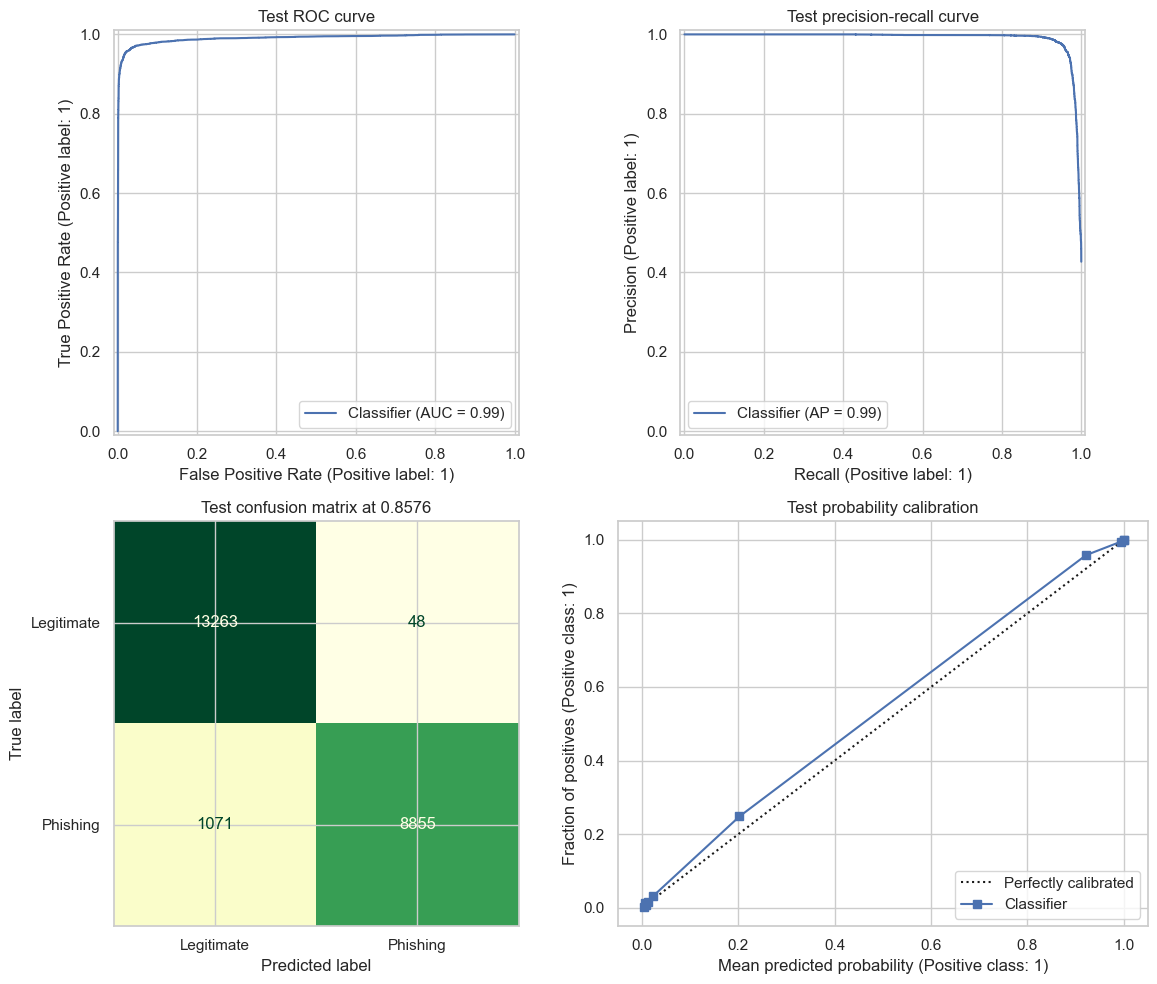

In [13]:
test_predictions = (test_probabilities >= decision_threshold).astype("int8")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
RocCurveDisplay.from_predictions(y_test, test_probabilities, ax=axes[0, 0])
axes[0, 0].set_title("Test ROC curve")
PrecisionRecallDisplay.from_predictions(y_test, test_probabilities, ax=axes[0, 1])
axes[0, 1].set_title("Test precision-recall curve")
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    display_labels=["Legitimate", "Phishing"],
    cmap="YlGn",
    colorbar=False,
    ax=axes[1, 0],
)
axes[1, 0].set_title(f"Test confusion matrix at {decision_threshold:.4f}")
CalibrationDisplay.from_predictions(
    y_test,
    test_probabilities,
    n_bins=10,
    strategy="quantile",
    ax=axes[1, 1],
)
axes[1, 1].set_title("Test probability calibration")
plt.tight_layout()
plt.show()

## 9. Error analysis and permutation importance

False positives and false negatives are displayed only for controlled analysis; do not click unfamiliar URLs. Permutation importance is computed on a bounded validation sample to keep the notebook lightweight.

In [14]:
test_audit = df.iloc[test_idx][["url"]].copy()
test_audit["registered_domain_group"] = groups.iloc[test_idx].to_numpy()
test_audit["is_phishing"] = y_test.to_numpy()
test_audit["phishing_probability"] = test_probabilities
test_audit["prediction"] = test_predictions

false_positives = test_audit.query("is_phishing == 0 and prediction == 1").sort_values(
    "phishing_probability", ascending=False
)
false_negatives = test_audit.query("is_phishing == 1 and prediction == 0").sort_values(
    "phishing_probability", ascending=True
)

print("False positives:", len(false_positives))
display(false_positives.head(10))
print("False negatives:", len(false_negatives))
display(false_negatives.head(10))

False positives: 48


,url,registered_domain_group,is_phishing,phishing_probability,prediction
53776,https://www.centre-international-carthage-medical.com/,centre-international-carthage-medical.com,0,0.999907,1
124442,https://www.doulmousi.asfalisinet.my-pro-office.gr/,my-pro-office.gr,0,0.999824,1
141492,https://www.70-billion-pixels-budapest.com/,70-billion-pixels-budapest.com,0,0.999648,1
108436,https://www.iswc2017.semanticweb.org/,semanticweb.org,0,0.999567,1
76956,https://www.6581-8580.com/,6581-8580.com,0,0.999102,1
181714,https://www.farmhouse30542.com/,farmhouse30542.com,0,0.999054,1
95405,https://www.graduateacademy.uni-heidelberg.de/,uni-heidelberg.de,0,0.998289,1
178458,https://www.ethnicity-facts-figures.service.gov.uk/,ethnicity-facts-figures.service.gov.uk,0,0.997821,1
166840,https://www.79798282.net/,79798282.net,0,0.997085,1
7182,https://www.publications.copernicus.org/,copernicus.org,0,0.996706,1


False negatives: 1071


,url,registered_domain_group,is_phishing,phishing_probability,prediction
172972,https://www.vmsuco.com/jp,vmsuco.com,1,0.001953,0
100813,https://www.webaxum.com/,webaxum.com,1,0.002959,0
181093,https://www.pajani.ir/,pajani.ir,1,0.005059,0
180210,https://unconloeinfka.repl.co/,unconloeinfka.repl.co,1,0.005477,0
39569,https://jofrasafaris.co.ke/,jofrasafaris.co.ke,1,0.005926,0
188419,https://mpgrobalse.web.app/,mpgrobalse.web.app,1,0.006047,0
53125,https://gkolpbdhka.web.app/,gkolpbdhka.web.app,1,0.006047,0
117180,https://a.cloudcentery.com/,cloudcentery.com,1,0.006074,0
166392,https://sigulemada.web.app/,sigulemada.web.app,1,0.006142,0
234343,https://cbsnjerpso.web.app/,cbsnjerpso.web.app,1,0.006163,0


,feature,mean_importance,std_importance
0,hostname_length,0.271663,0.002333
1,url_length,0.242285,0.003055
2,digit_count,0.062816,0.002381
3,host_label_count,0.048221,0.000286
4,max_host_label_length,0.042880,0.000635
5,hostname_entropy,0.007389,0.000291
6,special_count,0.002988,0.000333
7,url_entropy,0.002130,0.000164
8,special_ratio,0.001900,0.000045
9,tld_length,0.001146,0.000121


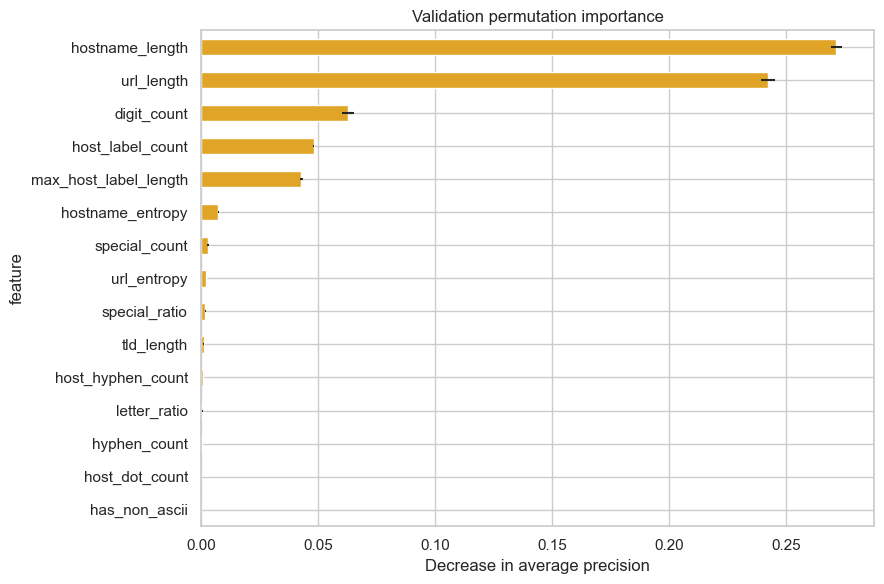

In [15]:
RUN_PERMUTATION_IMPORTANCE = True
importance_df = pd.DataFrame()

if RUN_PERMUTATION_IMPORTANCE:
    rng = np.random.default_rng(RANDOM_STATE)
    sample_size = min(10_000, len(X_val))
    sample_positions = rng.choice(len(X_val), size=sample_size, replace=False)
    importance = permutation_importance(
        calibrated_model,
        X_val.iloc[sample_positions],
        y_val.iloc[sample_positions],
        scoring="average_precision",
        n_repeats=3,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    importance_df = (
        pd.DataFrame(
            {
                "feature": FEATURE_COLUMNS,
                "mean_importance": importance.importances_mean,
                "std_importance": importance.importances_std,
            }
        )
        .sort_values("mean_importance", ascending=False)
        .reset_index(drop=True)
    )
    display(importance_df.head(15))
    importance_df.head(15).sort_values("mean_importance").plot.barh(
        x="feature",
        y="mean_importance",
        xerr="std_importance",
        figsize=(9, 6),
        color="#E0A526",
        legend=False,
    )
    plt.title("Validation permutation importance")
    plt.xlabel("Decrease in average precision")
    plt.tight_layout()
    plt.show()

## 10. Export a versioned inference bundle

The bundle contains the calibrated estimator, exact feature order, locked threshold, dataset/preprocessing fingerprints, and final metrics. Only load joblib artifacts produced by a trusted training process.

In [16]:
def json_safe_metrics(metrics):
    return {
        key: (int(value) if key in {"tn", "fp", "fn", "tp"} else float(value))
        for key, value in metrics.items()
    }

artifact_path = ARTIFACT_DIR / f"{MODEL_VERSION}.joblib"
metadata_path = ARTIFACT_DIR / f"{MODEL_VERSION}.metadata.json"
created_at = datetime.now(timezone.utc).isoformat()

metadata = {
    "artifact_version": "1.0",
    "model_version": MODEL_VERSION,
    "created_at_utc": created_at,
    "selected_model": selected_name,
    "target": TARGET,
    "positive_class": "phishing",
    "feature_columns": FEATURE_COLUMNS,
    "bias_excluded_columns": BIAS_EXCLUDED_COLUMNS,
    "decision_threshold": float(decision_threshold),
    "threshold_policy": {
        "source_split": "validation",
        "maximum_false_positive_rate": MAX_VALIDATION_FPR,
    },
    "split_policy": {
        "type": "StratifiedGroupKFold",
        "group": "public-suffix-aware registered domain",
        "private_suffixes": True,
        "random_state": RANDOM_STATE,
        "summary": split_summary,
    },
    "dataset": {
        "path": str(DATA_PATH.relative_to(PROJECT_ROOT)),
        "sha256": sha256_file(DATA_PATH),
        "rows": len(df),
        "preprocessing_pipeline_version": eda_summary["pipeline_version"],
    },
    "validation_metrics": json_safe_metrics(validation_metrics),
    "test_metrics": json_safe_metrics(test_metrics),
    "package_versions": {
        "python": platform.python_version(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scikit_learn": sklearn.__version__,
        "joblib": joblib.__version__,
        "tldextract": importlib.metadata.version("tldextract"),
    },
    "limitations": eda_summary["eda"]["warnings"],
}

if not importance_df.empty:
    metadata["top_permutation_importance"] = importance_df.head(15).to_dict(orient="records")

bundle = {
    "model": calibrated_model,
    "feature_columns": FEATURE_COLUMNS,
    "decision_threshold": float(decision_threshold),
    "metadata": metadata,
}
joblib.dump(bundle, artifact_path, compress=3)
metadata_path.write_text(
    json.dumps(metadata, indent=2, ensure_ascii=False) + "\n",
    encoding="utf-8",
)

print("Model bundle:", artifact_path)
print("Metadata:", metadata_path)
print("Bundle size (MB):", round(artifact_path.stat().st_size / 1024**2, 3))

Model bundle: C:\Users\kenne\Documents\Codes\Phisang\ai\url_classifier\artifacts\phisang-url-phishing-v1.joblib
Metadata: C:\Users\kenne\Documents\Codes\Phisang\ai\url_classifier\artifacts\phisang-url-phishing-v1.metadata.json
Bundle size (MB): 0.171


In [17]:
reloaded_bundle = joblib.load(artifact_path)
smoke_features = X_test.head(128)
before_reload = calibrated_model.predict_proba(smoke_features)[:, 1]
after_reload = reloaded_bundle["model"].predict_proba(smoke_features)[:, 1]

assert reloaded_bundle["feature_columns"] == FEATURE_COLUMNS
assert reloaded_bundle["decision_threshold"] == decision_threshold
assert np.allclose(before_reload, after_reload)

display(
    pd.DataFrame(
        {
            "model_version": [MODEL_VERSION],
            "selected_model": [selected_name],
            "threshold": [decision_threshold],
            "test_average_precision": [test_metrics["average_precision"]],
            "test_roc_auc": [test_metrics["roc_auc"]],
            "test_precision": [test_metrics["precision"]],
            "test_recall": [test_metrics["recall"]],
            "test_false_positive_rate": [test_metrics["false_positive_rate"]],
            "reload_smoke_test": ["passed"],
        }
    )
)

,model_version,selected_model,threshold,test_average_precision,test_roc_auc,test_precision,test_recall,test_false_positive_rate,reload_smoke_test
0,phisang-url-phishing-v1,hist_gradient_boosting,0.857579,0.990833,0.990605,0.994609,0.892102,0.003606,passed


## Next step

Integrate the exported bundle behind the URL feature extractor, but keep policy semantics conservative:

- URLhaus exact match: known malware.
- High classifier probability: suspected phishing.
- Intermediate probability: unknown or warning.
- Low probability: low observed URL risk, not proof of safety.

Before production use, evaluate this unchanged artifact on a newer independently sourced dataset with realistic legitimate deep links and query strings.